In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [2]:
device = "cuda:0"

### Квантизация свёрточных слоёв модели

In [3]:
class LSQFunction(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, scale, s_grad_scale, Qn, Qp):
        ctx.save_for_backward(x, scale)
        ctx.s_grad_scale = s_grad_scale
        ctx.Qn = Qn
        ctx.Qp = Qp
        
        x_scaled = x / scale
        x_clamped = torch.clamp(torch.round(x_scaled), Qn, Qp)
        x_quant = x_clamped * scale
        return x_quant

    @staticmethod
    def backward(ctx, grad_output):
        x, scale = ctx.saved_tensors
        s_grad_scale = ctx.s_grad_scale
        Qn, Qp = ctx.Qn, ctx.Qp
        
        x_scale = x / scale
        indicate_small = (x_scale <= Qn).float()
        indicate_big = (x_scale >= Qp).float()
        indicate_middle = 1.0 - indicate_small - indicate_big

        grad_scale = (indicate_small * Qn + indicate_big * Qp + 
                  indicate_middle * (-x_scale + torch.round(x_scale))) * grad_output
        grad_scale = grad_scale.sum().unsqueeze(0) * s_grad_scale
        
        grad_x = indicate_middle * grad_output
        
        return grad_x, grad_scale, None, None, None

In [4]:
class QAConv2d(nn.Conv2d):
    def __init__(self, in_channels, out_channels, kernel_size, n_bits=8, static_padding=None, **kwargs):
        super().__init__(in_channels, out_channels, kernel_size, **kwargs)
        self.n_bits = n_bits
        self.Qn = -2**(n_bits - 1)
        self.Qp = 2**(n_bits - 1) - 1
        
        self.static_padding = static_padding 
        self.weight_scale = nn.Parameter(torch.ones(1))
        self.x_scale = nn.Parameter(torch.ones(1))        
        self.initialized = False
        
        self.register_buffer('init_state', torch.tensor(False, dtype=torch.bool))
        with torch.no_grad():
            self.weight_scale.data.copy_(2 * self.weight.abs().mean() / (self.Qp**0.5))

    def forward(self, x):
        if self.static_padding is not None:
            x = self.static_padding(x)
        if self.training and not self.init_state:
            with torch.no_grad():
                self.x_scale.data.copy_(2 * max(x.abs().mean(), 1e-4) / (self.Qp**0.5))
                self.init_state.fill_(True)
        if self.training:
            weight_s_grad_scale = 1.0 / ((self.weight.numel() * self.Qp)**0.5)
            x_s_grad_scale = 1.0 / ((x.numel() * self.Qp)**0.5)
        else:
            weight_s_grad_scale =  x_s_grad_scale = 1.0

        quantized_weight = LSQFunction.apply(self.weight, self.weight_scale, weight_s_grad_scale, self.Qn, self.Qp)
        quantized_x = LSQFunction.apply(x, self.x_scale, x_s_grad_scale, self.Qn, self.Qp)

        return F.conv2d(quantized_x, quantized_weight, self.bias, self.stride, 
                        self.padding, self.dilation, self.groups)

In [5]:
def replace_conv_in_specific_parts(model, parts_to_replace=['encoder', 'decoder'], bit_width=8):
    """
    Заменяет свёртки на QAConv2d в указанных частях модели
    
    Args:
        model: модель
        parts_to_replace: ['encoder', 'decoder', 'segmentation_head']
        bit_width: количество бит для квантования
    """
    def  replace_conv_with_lsq(module, n_bits):
        if isinstance(module, QAConv2d):
            return

        for name, child in module.named_children():
            # вручную пропускаем свёртки, которые не хотим менять
            if name in ('_conv_stem', '_conv_head'):
                print(f'Пропускаем {name}')
                continue
            if isinstance(child, nn.Conv2d):
                static_padding = None
                if hasattr(child, 'static_padding') and child.static_padding is not None:
                    if not isinstance(child.static_padding, nn.Identity):
                        static_padding = child.static_padding

                bias = child.bias is not None

                lsq_conv = QAConv2d(
                    child.in_channels,
                    child.out_channels,
                    child.kernel_size,
                    n_bits=n_bits,
                    static_padding=static_padding,
                    stride=child.stride,
                    padding=child.padding,
                    dilation=child.dilation,
                    groups=child.groups,
                    bias=bias,
                )

                lsq_conv.weight.data.copy_(child.weight.data)
                if bias:
                    lsq_conv.bias.data.copy_(child.bias.data)

                setattr(module, name, lsq_conv)
            else:
                replace_conv_with_lsq(child, n_bits)
    

    if isinstance(parts_to_replace, str):
        parts_to_replace = [parts_to_replace]

    for part_name in parts_to_replace:
        if hasattr(model, part_name):
            part_module = getattr(model, part_name)
            replace_conv_with_lsq(part_module, bit_width)

In [6]:
import torch
from segmentation_models_pytorch import Unet as SMPUnet


class Unet(SMPUnet):
    """
    Кастомная реализация UNet с загрузкой весов энкодера из файла.
    """

    def __init__(
        self,
        encoder_name: str = 'efficientnet-b4',
        encoder_depth: int = 5,
        encoder_weights: str | None = None,
        decoder_use_batchnorm: bool = True,
        decoder_channels: list[int] = [256, 128, 64, 32, 16],
        decoder_attention_type: str | None = 'scse',
        in_channels: int = 3,
        classes: int = 27,
        activation: str | None = None,
        aux_params: dict | None = None,
        **kwargs,
    ):
        super().__init__(
            encoder_name=encoder_name,
            encoder_depth=encoder_depth,
            encoder_weights=None,
            decoder_use_batchnorm=decoder_use_batchnorm,
            decoder_channels=decoder_channels,
            decoder_attention_type=decoder_attention_type,
            in_channels=in_channels,
            classes=classes,
            activation=activation,
            aux_params=aux_params,
            **kwargs,
        )

        if encoder_weights is not None:
            state_dict = torch.load(encoder_weights, map_location='cpu')
            try:
                self.encoder.load_state_dict(state_dict, strict=False)
                print('Веса загружены вручную')
            except Exception as e:
                raise RuntimeError(
                    f'Не удалось загрузить веса из файла {weights_path}: {e}'
                )

/pub/home/tjumentseva/env/fields_segmentation/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
model = Unet(encoder_weights='/pub/home/tjumentseva/projects/fields_segmentation/weights/pretrained/efficientnet-b4-6ed6700e.pth')
model

Веса загружены вручную


Unet(
  (encoder): EfficientNetEncoder(
    (_conv_stem): Conv2dStaticSamePadding(
      3, 48, kernel_size=(3, 3), stride=(2, 2), bias=False
      (static_padding): ZeroPad2d((0, 1, 0, 1))
    )
    (_bn0): BatchNorm2d(48, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
    (_blocks): ModuleList(
      (0): MBConvBlock(
        (_expand_conv): Identity()
        (_bn0): Identity()
        (_depthwise_conv): Conv2dStaticSamePadding(
          48, 48, kernel_size=(3, 3), stride=[1, 1], groups=48, bias=False
          (static_padding): ZeroPad2d((1, 1, 1, 1))
        )
        (_bn1): BatchNorm2d(48, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
        (_se_reduce): Conv2dStaticSamePadding(
          48, 12, kernel_size=(1, 1), stride=(1, 1)
          (static_padding): Identity()
        )
        (_se_expand): Conv2dStaticSamePadding(
          12, 48, kernel_size=(1, 1), stride=(1, 1)
          (static_padding): Ident

In [8]:
replace_conv_in_specific_parts(model, parts_to_replace=['encoder', 'decoder'], bit_width=8)
model.to(device)
model

Пропускаем _conv_stem
Пропускаем _conv_head


Unet(
  (encoder): EfficientNetEncoder(
    (_conv_stem): Conv2dStaticSamePadding(
      3, 48, kernel_size=(3, 3), stride=(2, 2), bias=False
      (static_padding): ZeroPad2d((0, 1, 0, 1))
    )
    (_bn0): BatchNorm2d(48, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
    (_blocks): ModuleList(
      (0): MBConvBlock(
        (_expand_conv): Identity()
        (_bn0): Identity()
        (_depthwise_conv): QAConv2d(
          (static_padding): ZeroPad2d((1, 1, 1, 1))
          (conv): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1), groups=48, bias=False)
        )
        (_bn1): BatchNorm2d(48, eps=0.001, momentum=0.010000000000000009, affine=True, track_running_stats=True)
        (_se_reduce): QAConv2d(
          (conv): Conv2d(48, 12, kernel_size=(1, 1), stride=(1, 1))
        )
        (_se_expand): QAConv2d(
          (conv): Conv2d(12, 48, kernel_size=(1, 1), stride=(1, 1))
        )
        (_project_conv): QAConv2d(
          (conv): Conv2d

In [9]:
# проверка, что модель работает
example_tensor = torch.ones(
    (1, 3, 512, 512),
    dtype=torch.float32,
    device=device,
)
with torch.no_grad():
#     model(example_tensor)
    print(model(example_tensor).dtype, model(example_tensor).shape)

torch.float32 torch.Size([1, 27, 512, 512])


### Обучение модели
взято из [ноутбука](https://github.com/Tyumentseva/Unet-Inference-Acceleration-Project/blob/main/notebooks/model/train/train_COCO.ipynb)

In [ ]:
import numpy as np
import torch
from pycocotools.coco import COCO
from torch.utils.data import DataLoader, Dataset

import segmentation_models_pytorch as smp

from torchvision.transforms import v2 as tr
from torchvision import tv_tensors

import random
import matplotlib.pyplot as plt

import os
from pathlib import Path
import zipfile
from urllib.request import urlretrieve

import time
import copy
import torch.nn as nn

from PIL import Image as PILImage

from IPython.display import clear_output

from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

from termcolor import colored
from collections import defaultdict

from tqdm.auto import tqdm
import heapq

import colorsys
from torchvision.transforms import InterpolationMode
from torchvision.transforms.functional import pil_to_tensor

In [ ]:
IGNORE_INDEX = 255
NUM_WORKERS = 4
BATCH_SIZE = 16
IMAGE_SIZE = (384, 384)

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
NUM_CLASSES = 81
LR = 1e-3
WEIGHT_DECAY = 1e-4
EPOCHS = 20
WARM_EPOCHS = 6

# Установить True, если нужна точная воспроизводимость. Замедляет обучение!
FIX_SEED = True
SEED = 42

# TODO Понять как влияет на обучение и не мешает ли экспериментам.
USE_AMP = torch.cuda.is_available()

ROOT_DATASET = "/data/datasets/coco"
CKPT_DIR = "./weights/"
CKPT_TOPK_DIR = CKPT_DIR + "topk"

In [ ]:
def seed_everything(seed: int):
    os.environ["PYTHONHASHSEED"] = str(seed)

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def seed_worker(_worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

if FIX_SEED:
    seed_everything(SEED)
    seed_generator = torch.Generator()
    seed_generator.manual_seed(SEED)
else:
    seed_generator=None
    seed_worker = None

In [ ]:
class SegTransform:
    '''
    Класс-преобразователь, который применяет аугментации к паре (image, mask)
    '''
    
    def __init__(self, size, train=True):

        self.mean = IMAGENET_MEAN
        self.std = IMAGENET_STD

        if train:
            self.joint_prepare = tr.Compose([
                tr.RandomResizedCrop(
                    size,
                    scale=(0.6, 1.0),
                    interpolation=InterpolationMode.BILINEAR,
                    antialias=True
                ),
                tr.RandomHorizontalFlip(p=0.5),
            ])
        else:
            self.joint_prepare = tr.Compose([
                tr.Resize(size, interpolation=InterpolationMode.BILINEAR, antialias=True),
            ])

        if train:
            self.image_prepare = tr.Compose([
                tr.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0.02),
                tr.ToDtype(torch.float32, scale=True),
                tr.Normalize(mean=self.mean, std=self.std),
            ])
        else:
            self.image_prepare = tr.Compose([
                tr.ToDtype(torch.float32, scale=True),
                tr.Normalize(mean=self.mean, std=self.std),
            ])

    def __call__(self, image, mask):
        image = tv_tensors.Image(image)
        mask = tv_tensors.Mask(pil_to_tensor(mask).squeeze(0).to(torch.int64))  # без np.array

        image, mask = self.joint_prepare(image, mask)
        image = self.image_prepare(image)
        return image, mask.long()

In [ ]:
def seg_collate_fn(batch):
    images, masks = zip(*batch)
    images = torch.stack(images, dim=0)
    masks = torch.stack(masks, dim=0)
    return images, masks

In [ ]:
class COCOSemanticDataset(Dataset):
    """
    Semantic-seg dataset на базе COCO instances.
    Возвращает:
      image: PIL.Image (RGB)
      mask:  PIL.Image (L), где:
             0 = background
             1..N = категории COCO (плотная перенумерация)
             ignore_index (по умолчанию 255) можно использовать при необходимости
    """

    def __init__(
        self,
        root=ROOT_DATASET,
        split="train2017",
        masks_root="semantic_masks",
        ann_file=None,
        transforms=None,
        ignore_index=IGNORE_INDEX,
    ):
        self.root = Path(root)
        self.split = split
        self.transforms = transforms
        self.ignore_index = ignore_index

        self.images_dir = self.root / split
        self.masks_dir = self.root / masks_root / split

        if ann_file is None:
            ann_file = self.root / "annotations" / f"instances_{split}.json"
        self.coco = COCO(str(ann_file))

        self.image_ids = sorted(self.coco.getImgIds())

        cat_ids = sorted(self.coco.getCatIds())
        cats = self.coco.loadCats(cat_ids)
        self.class_names = ["background"] + [c["name"] for c in sorted(cats, key=lambda x: x["id"])]
        self.num_classes = len(self.class_names)

        # Проверка наличия масок
        missing = 0
        for image_id in self.image_ids[:500]:  # быстрая проверка части
            info = self.coco.loadImgs(image_id)[0]
            mpath = self.masks_dir / (Path(info["file_name"]).stem + ".png")
            if not mpath.exists():
                missing += 1
        if missing > 0:
            raise FileNotFoundError(
                f"Missing precomputed masks in {self.masks_dir}. "
                f"Run build_coco_semantic_masks(...) first."
            )

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        info = self.coco.loadImgs(image_id)[0]

        image_path = self.images_dir / info["file_name"]
        mask_path = self.masks_dir / (Path(info["file_name"]).stem + ".png")

        with PILImage.open(image_path) as im:
            image = im.convert("RGB").copy()

        with PILImage.open(mask_path) as mm:
            mask = mm.convert("L").copy()

        if self.transforms is not None:
            image, mask = self.transforms(image, mask)

        return image, mask

In [ ]:
train_ds = COCOSemanticDataset(
    root=ROOT_DATASET,
    split="train2017",
    masks_root="semantic_masks",
    transforms=SegTransform(size=IMAGE_SIZE, train=True),
)

val_ds = COCOSemanticDataset(
    root=ROOT_DATASET,
    split="val2017",
    masks_root="semantic_masks",
    transforms=SegTransform(size=IMAGE_SIZE, train=False),
)

In [ ]:
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=False,
    prefetch_factor=2,
    collate_fn=seg_collate_fn,
    worker_init_fn=seed_worker,
    generator=seed_generator,
    timeout= 60,
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=False,
    prefetch_factor=2,
    collate_fn=seg_collate_fn,
    worker_init_fn=seed_worker,
    generator=seed_generator,
    timeout= 60,
)

In [ ]:
@torch.no_grad()
def _update_confmat(confmat, logits, target, num_classes=NUM_CLASSES, ignore_index=IGNORE_INDEX):
    # logits: [B, C, H, W], target: [B, H, W]
    pred = logits.argmax(dim=1)
    valid = target != ignore_index
    pred = pred[valid]
    target = target[valid]
    if target.numel() == 0:
        return confmat

    idx = target * num_classes + pred
    binc = torch.bincount(idx, minlength=num_classes * num_classes)
    confmat += binc.reshape(num_classes, num_classes)
    return confmat


@torch.no_grad()
def _miou_from_confmat(confmat):
    # IoU_c = TP / (TP + FP + FN)
    tp = confmat.diag()
    fp = confmat.sum(dim=0) - tp
    fn = confmat.sum(dim=1) - tp
    denom = tp + fp + fn
    iou = tp.float() / torch.clamp(denom.float(), min=1.0)
    return iou.mean().item(), iou.cpu()

In [ ]:
def train_one_epoch(
    model,
    loader,
    optimizer,
    criterion,
    scaler,
    device,
    num_classes=NUM_CLASSES,
    ignore_index=IGNORE_INDEX,
    max_bad_batches=5,
    grad_clip=1.0,
    epoch_idx=None,
    ):
    model.train()
    processed_samples = 0
    bad_batches = 0

    confmat = torch.zeros((num_classes, num_classes), device=device, dtype=torch.int64)

    use_cuda_amp = USE_AMP and str(device).startswith("cuda")
    amp_dtype = (
        torch.bfloat16
        if use_cuda_amp and torch.cuda.is_bf16_supported()
        else torch.float16
    )

    running_loss_sum = torch.zeros((), device=device)

    for bidx, (images, masks) in enumerate(tqdm(loader, mininterval=2.0)):
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        if masks.dtype != torch.long:
            masks = masks.long()
            print("bidx=", bidx, " masks.dtype != torch.long:")
        
        # батч целиком ignore может получиться из-за crop. loss может стать nan/inf — пропускаем
        valid = masks != ignore_index
        if not valid.any():
            continue

        # Проверка на лишние лишние классы
        # t = masks[valid]
        # t_min = int(t.min().item())
        # t_max = int(t.max().item())
        # if t_min < 0 or t_max >= num_classes:
        #     bad_batches += 1
        #     print(
        #         f"[bad-target] epoch={epoch_idx} batch={bidx} "
        #         f"min={t_min} max={t_max} num_classes={num_classes}"
        #     )
        #     if bad_batches >= max_bad_batches:
        #         raise RuntimeError("Too many bad batches: invalid targets")
        #     continue

        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast('cuda', dtype=amp_dtype , enabled=use_cuda_amp):
            logits = model(images)

            # if not torch.isfinite(logits).all():
            #     bad_batches += 1
            #     print(f"[bad-logits] epoch={epoch_idx} batch={bidx}")
            #     if bad_batches >= max_bad_batches:
            #         raise RuntimeError("Too many bad batches: non-finite logits")
            #     continue

            loss = criterion(logits, masks)
        
        if not torch.isfinite(loss):
            bad_batches += 1
            print(f"[bad-loss] epoch={epoch_idx} batch={bidx} loss={loss.detach().item()}")
            if bad_batches >= max_bad_batches:
                raise RuntimeError("Too many bad batches: non-finite loss")
            continue

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)

        grad_norm = torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=grad_clip,
            error_if_nonfinite=False,
        )
        if not torch.isfinite(grad_norm):
            bad_batches += 1
            print(f"[bad-grad] epoch={epoch_idx} batch={bidx} grad_norm={float(grad_norm)}")
            optimizer.zero_grad(set_to_none=True)
            if bad_batches >= max_bad_batches:
                raise RuntimeError("Too many bad batches: non-finite gradients")
            continue

        scaler.step(optimizer)
        scaler.update()

        bs = images.size(0)
        running_loss_sum += loss.detach() * bs
        processed_samples += bs
        _update_confmat(confmat, logits, masks, num_classes, ignore_index)
    
    if processed_samples == 0:
        raise RuntimeError(f"All batches skipped in epoch={epoch_idx}")

    epoch_loss = (running_loss_sum / processed_samples).item()
    epoch_miou, _ = _miou_from_confmat(confmat)

    if bad_batches > 0:
        print(f"[warn] epoch={epoch_idx} bad_batches={bad_batches}")

    return epoch_loss, epoch_miou

@torch.no_grad()
def evaluate(model, loader, criterion, device, num_classes=NUM_CLASSES, ignore_index=IGNORE_INDEX):
    model.eval()

    confmat = torch.zeros((num_classes, num_classes), device=device, dtype=torch.int64)
    running_loss_sum = torch.zeros((), device=device)
    processed_samples = 0

    # use_cuda_amp = USE_AMP and str(device).startswith("cuda")
    # amp_dtype = (
    #     torch.bfloat16
    #     if use_cuda_amp and torch.cuda.is_bf16_supported()
    #     else torch.float16
    # )

    # for bidx, (images, masks) in enumerate(loader):
    for bidx, (images, masks) in enumerate(tqdm(loader, mininterval=2.0)):
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True).long()

        # with torch.amp.autocast("cuda", dtype=amp_dtype, enabled=use_cuda_amp):
        #     logits = model(images)
        #     loss = criterion(logits, masks)
        
        logits = model(images)

        valid = masks != ignore_index
        if not valid.any():
            continue

        t = masks[valid]
        t_min = int(t.min().item())
        t_max = int(t.max().item())
        if t_min < 0 or t_max >= num_classes:
            raise RuntimeError(f"[eval bad-target] batch={bidx} min={t_min} max={t_max}")

        loss = criterion(logits, masks)
        if not torch.isfinite(loss):
            raise RuntimeError(f"[eval bad-loss] batch={bidx} loss={loss.detach().item()}")

        bs = images.size(0)
        running_loss_sum += loss.detach() * bs
        processed_samples += bs
        _update_confmat(confmat, logits, masks, num_classes, ignore_index)

    if processed_samples == 0:
        raise RuntimeError("All eval batches skipped")

    epoch_loss = (running_loss_sum / processed_samples).item()
    epoch_miou, class_iou = _miou_from_confmat(confmat)
    return epoch_loss, epoch_miou, class_iou

In [ ]:
def save_topk_checkpoint(
    model,
    epoch,
    train_miou,
    val_miou,
    history,
    optimizer=None,
    scheduler=None,
    scaler=None,
    ckpt_dir=CKPT_TOPK_DIR,
    top_k=3,
    heap_state=None,
):
    os.makedirs(ckpt_dir, exist_ok=True)
    if heap_state is None:
        heap_state = []  # (val_miou, path)

    ckpt_path = os.path.join(
        ckpt_dir, f"epoch_{epoch:03d}_val_{val_miou:.4f}_train_{train_miou:.4f}.pt"
    )

    payload = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict() if optimizer is not None else None,
        "scheduler_state_dict": scheduler.state_dict() if scheduler is not None else None,
        "scaler_state_dict": scaler.state_dict() if scaler is not None else None,
        "train_miou": float(train_miou),
        "val_miou": float(val_miou),
        "history": history,
    }

    if len(heap_state) < top_k:
        torch.save(payload, ckpt_path)
        heapq.heappush(heap_state, (val_miou, ckpt_path))
    else:
        worst_miou, worst_path = heap_state[0]
        if val_miou > worst_miou:
            heapq.heapreplace(heap_state, (val_miou, ckpt_path))
            if os.path.exists(worst_path):
                os.remove(worst_path)
            torch.save(payload, ckpt_path)

    return heap_state

In [ ]:
def learning_loop(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    epochs,
    device,
    scaler=None,
    scheduler=None,
    num_classes=NUM_CLASSES,
    ignore_index=IGNORE_INDEX,
    verbose=True,
    plot_live=True,
):
    """Полный цикл обучения + валидация + live-графики + best checkpoint."""

    if scaler is None:
        scaler = torch.amp.GradScaler('cuda', enabled=USE_AMP)

    history = {
        "train_loss": [],
        "train_miou": [],
        "val_loss": [],
        "val_miou": [],
        "lr": [],
    }
    
    best_val_miou = -1.0
    best_state = copy.deepcopy(model.state_dict())

    def _plot_history():
        ep = range(1, len(history["train_loss"]) + 1)
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        axes[0].plot(ep, history["train_loss"], label="train")
        axes[0].plot(ep, history["val_loss"], label="val")
        axes[0].set_title("Loss")
        axes[0].set_xlabel("Epoch")
        axes[0].grid(True, alpha=0.3)
        axes[0].legend()

        axes[1].plot(ep, history["train_miou"], label="train")
        axes[1].plot(ep, history["val_miou"], label="val")
        axes[1].set_title("mIoU")
        axes[1].set_xlabel("Epoch")
        axes[1].grid(True, alpha=0.3)
        axes[1].legend()

        axes[2].plot(ep, history["lr"], label="lr")
        axes[2].set_title("Learning Rate")
        axes[2].set_xlabel("Epoch")
        axes[2].grid(True, alpha=0.3)
        axes[2].legend()

        plt.tight_layout()
        plt.show()

    topk_heap = []

    for epoch in range(1, epochs + 1):
        t0 = time.time()

        train_loss, train_miou = train_one_epoch(
            model=model,
            loader=train_loader,
            optimizer=optimizer,
            criterion=criterion,
            scaler=scaler,
            device=device,
            num_classes=num_classes,
            ignore_index=ignore_index,
            epoch_idx=epoch
        )

        val_loss, val_miou, _ = evaluate(
            model=model,
            loader=val_loader,
            criterion=criterion,
            device=device,
            num_classes=num_classes,
            ignore_index=ignore_index,
        )

        current_lr = optimizer.param_groups[0]["lr"]

        history["train_loss"].append(train_loss)
        history["train_miou"].append(train_miou)
        history["val_loss"].append(val_loss)
        history["val_miou"].append(val_miou)
        history["lr"].append(current_lr)

        if scheduler is not None:
            scheduler.step()

        if val_miou > best_val_miou:
            best_val_miou = val_miou
            best_state = copy.deepcopy(model.state_dict())
        
        topk_heap = save_topk_checkpoint(
            model=model,
            epoch=epoch,
            train_miou=train_miou,
            val_miou=val_miou,
            history=history,
            optimizer=optimizer,
            scheduler=scheduler,
            scaler=scaler,
            ckpt_dir=CKPT_TOPK_DIR,
            top_k=10,
            heap_state=topk_heap,
        )

        if verbose:
            dt = time.time() - t0
            print(
                f"Epoch {epoch:02d}/{epochs} | "
                f"train_loss={train_loss:.4f} train_mIoU={train_miou:.4f} | "
                f"val_loss={val_loss:.4f} val_mIoU={val_miou:.4f} | "
                f"lr={current_lr:.2e} | time={dt:.1f}s"
            )

        if plot_live:
            clear_output(wait=True)
            _plot_history()

    model.load_state_dict(best_state)

    if not plot_live:
        _plot_history()

    return model, history, best_val_miou, topk_heap

In [ ]:
# С замороженным энкодером (тогда можно квантизовать свёртки только в декодере)
for p in model.encoder.parameters():
    p.requires_grad = False

# либо оставить scale обучаемым в энкодере, а остальные веса заморозить

In [ ]:
criterion = torch.nn.CrossEntropyLoss(ignore_index=IGNORE_INDEX)

optimizer = torch.optim.AdamW(
    (p for p in model.parameters() if p.requires_grad),
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)

scheduler = torch.optim.lr_scheduler.SequentialLR(
    optimizer,
    schedulers=[
        torch.optim.lr_scheduler.ConstantLR(
            optimizer,
            factor=1.0,
            total_iters=WARM_EPOCHS,
        ),
        torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer,
            T_max=EPOCHS - WARM_EPOCHS,
            eta_min=1e-5,
        ),
    ],
    milestones=[WARM_EPOCHS],
)

scaler = torch.amp.GradScaler('cuda', enabled=USE_AMP)

In [ ]:
model, history, best_val_miou, topk_heap = learning_loop(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    criterion=criterion,
    epochs=EPOCHS,
    device=DEVICE,
    scaler=scaler,
    scheduler=scheduler,
    num_classes=NUM_CLASSES,
    ignore_index=IGNORE_INDEX,
)

In [ ]:
print("Best val mIoU:", round(best_val_miou, 4))

### Визуализация выбора инициализации квантизованных весов

Ячейки проживать не надо

In [9]:
def find_qaconv2d_modules(model):
    """Находит все экземпляры QAConv2d в модели"""
    qaconv2d_list = []
    
    def search_recursive(module):
        for name, child in module.named_children():
            if isinstance(child, QAConv2d):
                qaconv2d_list.append((name, child))
            else:
                search_recursive(child)
    
    search_recursive(model)
    return qaconv2d_list

qaconv2d_modules = find_qaconv2d_modules(model)
print(f"Найден QAConv2d: {qaconv2d_modules[0][1]}")
print(f"  Веса: {qaconv2d_modules[0][1].conv.weight.shape}")

Найден QAConv2d: QAConv2d(
  (conv): Conv2d(608, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
)
  Веса: torch.Size([256, 608, 3, 3])


<Figure size 1000x700 with 0 Axes>

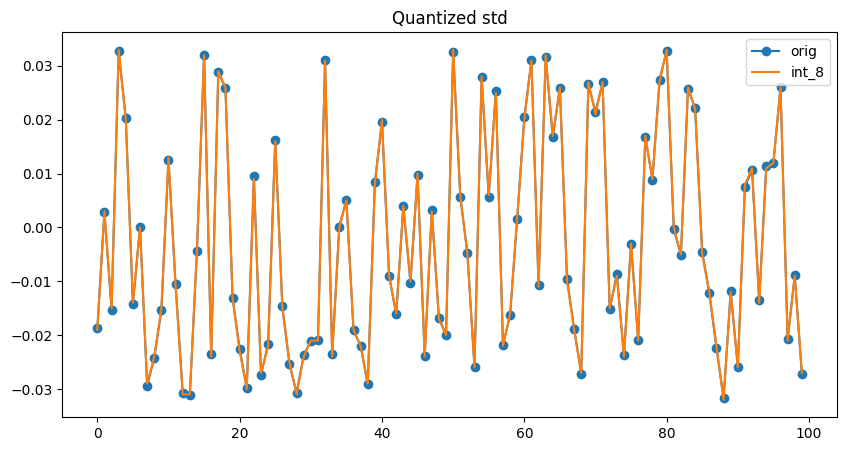

In [10]:
import numpy as np
import matplotlib.pyplot as plt

module = qaconv2d_modules[0][1]

ex_tensor = qaconv2d_modules[0][1].conv.weight.data

plt.figure(figsize=(10,7))
f = plt.figure(figsize = (10, 5))

vector_orig = ex_tensor.cpu().numpy().flatten()[:100]
plt.plot(range(len(vector_orig)), vector_orig, label='orig', marker='o')


dequantized_tensor = module.quantizer(
    module.conv.weight, 
    module.weight_step, 
    module.bit
)
dequantized = dequantized_tensor.cpu().detach().numpy()
vector_dequantized = dequantized.flatten()[:100]

plt.plot(range(len(vector_dequantized)), vector_dequantized, label='int_8')

plt.title('Quantized std');
plt.legend();

<Figure size 1000x700 with 0 Axes>

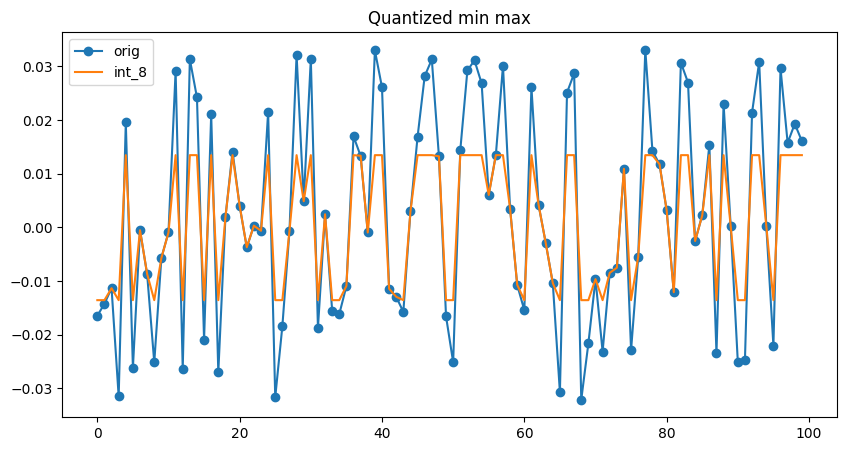

In [12]:
import numpy as np
import matplotlib.pyplot as plt

ex_tensor = qaconv2d_modules[0][1].conv.weight.data

plt.figure(figsize=(10,7))

f = plt.figure(figsize = (10, 5))

vector_orig = ex_tensor.cpu().numpy().flatten()[:100]
plt.plot(range(len(vector_orig)), vector_orig, label='orig', marker='o')

dequantized_tensor = module.quantizer(
    module.conv.weight, 
    module.weight_step, 
    module.bit
)
dequantized = dequantized_tensor.cpu().detach().numpy()
vector_dequantized = dequantized.flatten()[:100]

plt.plot(range(len(vector_dequantized)), vector_dequantized, label='int_8')

plt.title('Quantized min max');
plt.legend();